# Calibration & abstention

Reproduces the **calibration / abstention** panels of the DeepCell Types paper.
These diagnostics characterize the **frozen-CLS max-softmax** confidence and the
**per-(tissue, modality) IQR-fence cell-type abstention** policy used at the
paper's headline operating point (**k = 0.2**):

- **calibration_reliability** — reliability diagram (12-bin, ±5 pp envelope) + ECE.
- **calibration_confidence_by_correctness** — confidence histograms split by
  hierarchical correctness, with the median IQR fence overlaid.
- **iqr_coverage_macro_f1_pareto** — coverage vs macro-F1 Pareto for the
  per-group IQR fence vs a global max-softmax threshold τ; paper operating point starred.
- **iqr_per_class_abstention_rate** — per-class abstention rate at k = 0.2 (lineage-colored).
- **iqr_per_group_fence** — the actual per-(tissue, modality) fence values (modality-colored).
- **calibration_reliability_by_lineage** — reliability stratified by true-label lineage.
- **iqr_pareto_macro_f1 / iqr_pareto_weighted_f1** — val-picked-operating-point Pareto
  curves from the precomputed val→test IQR sweep JSON.
- **fov_abstention_exemplar** — a held-out test FOV showing where abstention triggers
  (correct / mispredicted / abstained cells).

The IQR fence is computed via the torch-free vendored `dct_figures.scoring`
helpers; per-group buckets come from the v10 zarr archive attrs. Figures are
styled to the **Science Advances 2026** figure spec via `dct_figures.style`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

The workspace script pulls `ct2idx` and `lineage_mapping` from a
`TissueNetConfig` (which imports `torch`). Here we use the torch-free vendored
`scoring.CT2IDX` (51-class canonical order), the analysis lineage taxonomy from
`data/lineage_mapping.yaml`, and the per-(tissue, modality) group metadata read
from the v10 zarr archive attrs.

We load the Frozen-CLS test predictions once and derive: per-cell max-softmax
confidence, argmax prediction, hierarchical-correctness flag
(`scoring.CELL_TYPE_HIERARCHY`), and the per-cell `tissue|modality` group key
used by the IQR fence.

In [2]:
import yaml
from dct_figures.scoring import CELL_TYPE_HIERARCHY, adjust_conf_mat_hierarchy

ct2idx = scoring.CT2IDX
idx2ct = {v: k for k, v in ct2idx.items()}
n_classes = len(ct2idx)

with open(paths.DATA_ROOT / 'lineage_mapping.yaml') as f:
    lineage_map = yaml.safe_load(f)

OPERATING_K = 0.2  # paper headline operating point
FROZEN_CLS_CSV = paths.OUTPUT / 'final_frozen_cls_test_prediction.csv'

# (tissue, modality) per dataset, from the v10 zarr archive attrs. The
# workspace script upper-cases modality for the panel-E colors; mirror that.
_meta = scoring.load_dataset_metadata(paths.EXPANDED_TISSUENET_ZARR).copy()
_meta['modality'] = _meta['modality'].fillna('unknown').astype(str).str.upper()
_meta['tissue'] = _meta['tissue'].fillna('unknown').astype(str)

_df_raw = pd.read_csv(paths.need(FROZEN_CLS_CSV))
class_cols = [c for c in _df_raw.columns if c in ct2idx]
_probs = _df_raw[class_cols].to_numpy(dtype=np.float32)
_pred_i = _probs.argmax(axis=1)
max_prob = _probs[np.arange(_probs.shape[0]), _pred_i]
pred_labels = np.array(class_cols)[_pred_i]
true_labels = _df_raw['cell_type_actual'].to_numpy(dtype=str)

# (tissue, modality) group key per cell.
_m = _df_raw[['dataset_name']].merge(_meta, on='dataset_name', how='left')
_m['tissue'] = _m['tissue'].fillna('unknown')
_m['modality'] = _m['modality'].fillna('unknown')
groups = (_m['tissue'].astype(str) + '|' + _m['modality'].astype(str)).to_numpy()
modalities = _m['modality'].to_numpy()


def _hier_correct(true_l, pred_l):
    correct = (true_l == pred_l)
    for parent, children in CELL_TYPE_HIERARCHY.items():
        forgive = (true_l == parent) & np.isin(pred_l, list(children))
        correct = correct | forgive
    return correct

correct = _hier_correct(true_labels, pred_labels)
print(f'{len(max_prob):,} cells | {len(np.unique(groups))} (tissue, modality) groups '
      f'| baseline hier-correct = {correct.mean()*100:.2f}%')

486,705 cells | 11 (tissue, modality) groups | baseline hier-correct = 89.77%


### IQR fence + scoring primitives

The per-group Tukey lower fence, the kept-mask, the IQR k-sweep, and the
global-threshold τ-sweep — all lifted verbatim from
`plot_calibration_and_abstention.py` (torch-free; the scoring is the same
hierarchy-adjusted macro/weighted F1 used elsewhere).

In [3]:
def _score(true_l, pred_l):
    n = len(ct2idx)
    cm = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(true_l, pred_l):
        if t in ct2idx and p in ct2idx:
            cm[ct2idx[t], ct2idx[p]] += 1
    cm = adjust_conf_mat_hierarchy(cm, CELL_TYPE_HIERARCHY, ct2idx)
    support = cm.sum(axis=1)
    has = support > 0
    tp = np.diag(cm).astype(float)
    pred_sum = cm.sum(axis=0).astype(float)
    recall = np.zeros_like(tp); precision = np.zeros_like(tp)
    np.divide(tp, support, out=recall, where=support > 0)
    np.divide(tp, pred_sum, out=precision, where=pred_sum > 0)
    f1 = np.zeros_like(tp); denom = recall + precision
    np.divide(2 * recall * precision, denom, out=f1, where=denom > 0)
    return {'macro_acc': float(recall[has].mean() * 100.0),
            'macro_f1': float(f1[has].mean() * 100.0)}


def _group_fences(mp, grps, k):
    out = {}
    for g in np.unique(grps):
        v = mp[grps == g]
        if len(v) < 4:
            out[g] = -np.inf
            continue
        q1, q3 = np.quantile(v, [0.25, 0.75])
        out[g] = float(q1 - k * (q3 - q1))
    return out


def _iqr_keep(mp, grps, k):
    fences = _group_fences(mp, grps, k)
    fence_per_cell = np.array([fences[g] for g in grps])
    return mp >= fence_per_cell, fences


def _iqr_sweep(mp, grps, true_l, pred_l, ks):
    rows = [{'k': None, 'coverage': 1.0, **_score(true_l, pred_l)}]
    for k in ks:
        keep, _ = _iqr_keep(mp, grps, k)
        rows.append({'k': float(k), 'coverage': float(keep.mean()),
                     **_score(true_l[keep], pred_l[keep])})
    return rows


def _global_threshold_sweep(mp, true_l, pred_l, taus):
    rows = []
    for tau in taus:
        keep = mp >= tau
        if keep.sum() == 0:
            continue
        rows.append({'tau': float(tau), 'coverage': float(keep.mean()),
                     **_score(true_l[keep], pred_l[keep])})
    return rows


KS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
TAUS = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

iqr_rows = _iqr_sweep(max_prob, groups, true_labels, pred_labels, KS)
tau_rows = _global_threshold_sweep(max_prob, true_labels, pred_labels, TAUS)
keep_op, fences_op = _iqr_keep(max_prob, groups, OPERATING_K)
median_fence = float(np.median([v for v in fences_op.values() if np.isfinite(v)]))
print(f'k={OPERATING_K}: coverage={keep_op.mean()*100:.2f}%, median fence={median_fence:.3f}')

k=0.2: coverage=82.06%, median fence=0.578


## calibration_reliability

Reliability diagram for the Frozen-CLS softmax (test split, 12-bin, ±5 pp
envelope). The model is rank-ordered but over-confident; the 15-bin ECE is
printed in the corner.

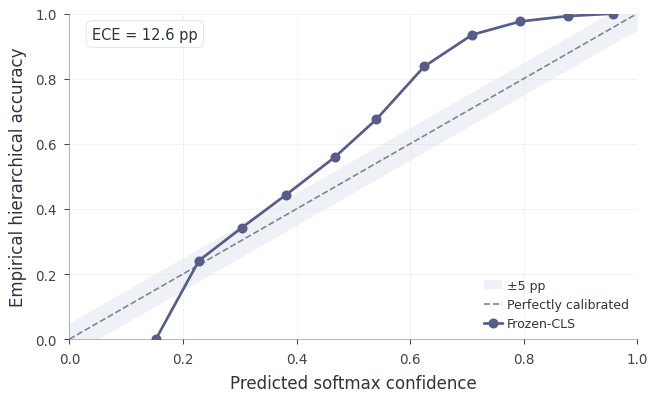

In [4]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_A(ax, max_prob, correct):
    n_bins = 12
    bin_edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(max_prob, bin_edges) - 1, 0, n_bins - 1)
    conf = centers.copy()
    acc = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        if m.any():
            conf[i] = max_prob[m].mean(); acc[i] = correct[m].mean()
            counts[i] = int(m.sum())
    valid = counts > 0
    xs = np.linspace(0, 1, 200)
    ax.fill_between(xs, np.clip(xs - 0.05, 0, 1), np.clip(xs + 0.05, 0, 1),
                    color=PAL['light_gray'], alpha=0.4, linewidth=0, zorder=1,
                    label='±5 pp')
    ax.plot([0, 1], [0, 1], color=PAL['gray'], linestyle='--', linewidth=0.8,
            label='Perfectly calibrated', zorder=2)
    ax.plot(conf[valid], acc[valid], marker='o', color=PAL['theme'],
            linewidth=1.3, markersize=3.8, label='Frozen-CLS', zorder=4)
    edges15 = np.linspace(0, 1, 16)
    idx15 = np.clip(np.digitize(max_prob, edges15) - 1, 0, 14)
    n = len(max_prob); ece = 0.0
    for i in range(15):
        m = idx15 == i
        if m.any():
            ece += (m.sum() / n) * abs(correct[m].mean() - max_prob[m].mean())
    ax.text(0.04, 0.96, f'ECE = {ece * 100:.1f} pp', transform=ax.transAxes,
            ha='left', va='top', fontsize=7.0,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=PAL['light_gray'], alpha=0.9))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted softmax confidence')
    ax.set_ylabel('Empirical hierarchical accuracy')
    ax.legend(loc='lower right', fontsize=6.0, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='both')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_A(ax, max_prob, correct)
fig.tight_layout()
plt.show()

## calibration_confidence_by_correctness

Max-softmax confidence histograms split by hierarchical correctness, with the
**median per-(tissue, modality) IQR fence** at the operating k overlaid (dashed
line) — the abstention precision the policy is trading on.

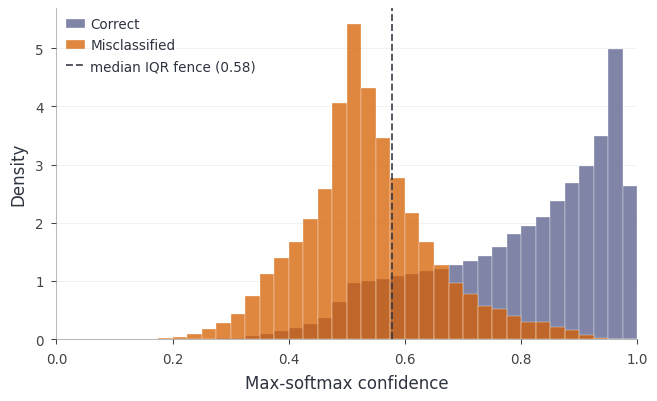

In [5]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_B(ax, max_prob, correct, median_fence):
    bins = np.linspace(0, 1, 41)
    ax.hist(max_prob[correct], bins=bins, color=PAL['theme'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Correct')
    ax.hist(max_prob[~correct], bins=bins, color=PAL['red'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Misclassified')
    ax.axvline(median_fence, color=PAL['dark'], linestyle='--', linewidth=0.9,
               alpha=0.85, zorder=5,
               label=f'median IQR fence ({median_fence:.2f})')
    ax.set_xlabel('Max-softmax confidence'); ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left', fontsize=6.5, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='y')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_B(ax, max_prob, correct, median_fence)
fig.tight_layout()
plt.show()